In [8]:
import sys 
from pathlib import Path
sys.path.append(str(Path(__name__).resolve().parents[2]))

from utils.dataset import ProcessedDataset
from utils.dna import Genes, create_template_from_genes
from pathlib import Path

import numpy as np 
import pandas as pd 
from tqdm import tqdm 
import pickle 
import matplotlib.pyplot as plt

# Load data

In [9]:
DATA_DIR = Path(__name__).resolve().parents[2] / 'data'
DATASET_DIR = DATA_DIR / "faces_dnas_2024_04_07_embeddings"

In [10]:
dataset = ProcessedDataset(DATASET_DIR)

100%|██████████| 1/1 [00:00<00:00, 415.65it/s]


In [13]:
from collections import defaultdict

gene_names = [p.split('/')[-2] for p in dataset.paths]
embeddings = dataset.model2normalized_embeddings["arcface-r100"]
gene2embeddings = defaultdict(list)
for gene, emb in zip(gene_names, embeddings):
    gene2embeddings[gene].append(emb)

# Embedding sensitivity analysis

<Axes: >

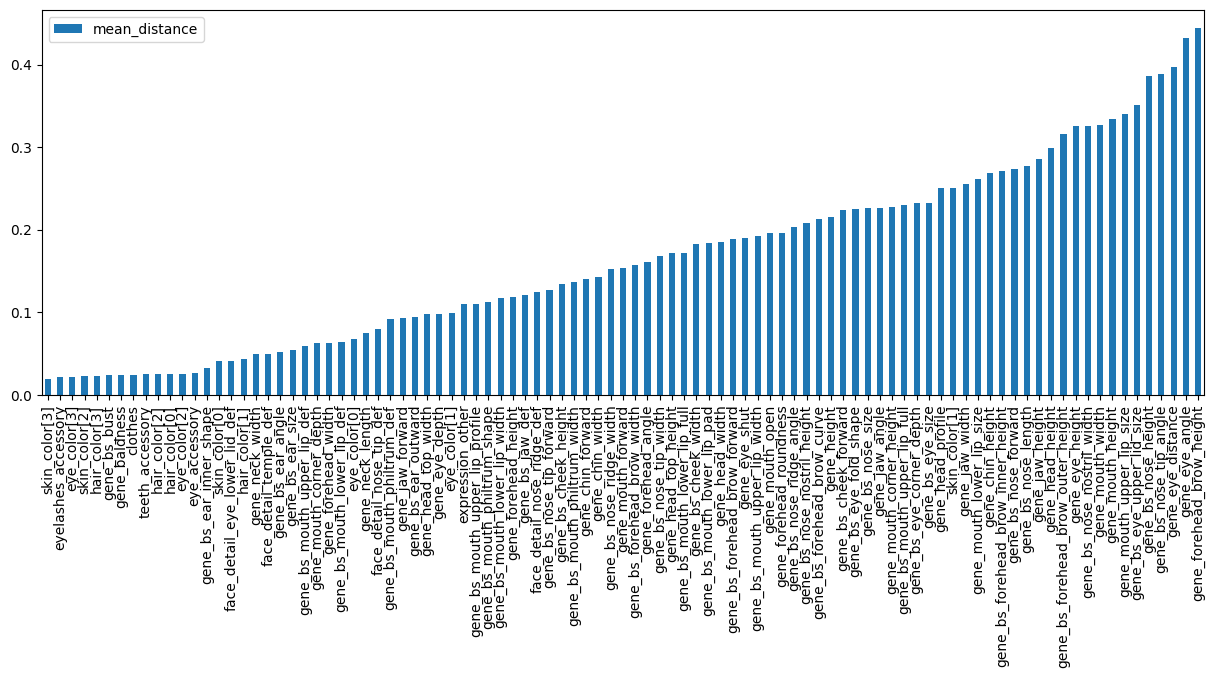

In [14]:
# create dataframe with mean distance between embeddings of the same gene
mean_distances = []
for gene, emb in gene2embeddings.items():
    emb = np.array(emb)
    distances = np.linalg.norm(emb - emb.mean(axis=0), axis=1)
    mean_distances.append(distances.mean())

df = pd.DataFrame(mean_distances, index=gene2embeddings.keys(), columns=["mean_distance"])
df = df.sort_values(by="mean_distance", ascending=True)
df.plot(kind='bar', figsize=(15, 5))

/var/folders/j2/83k2pfk133n_vkpjy9xj72c00000gn/T/ipykernel_65448/2655825002.py:35: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  plt.legend(df["category"].unique())


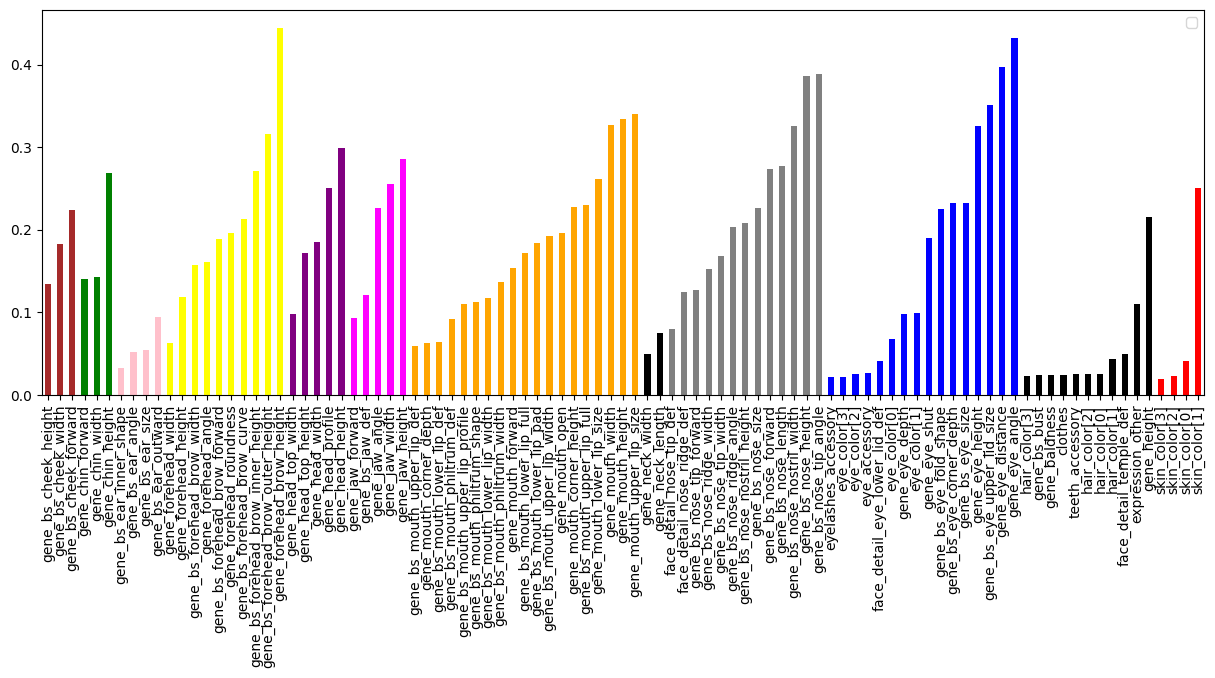

In [42]:
cat2color = {
    "skin": "red",
    "eye": "blue",
    "_chin": "green",
    "_forehead": "yellow",
    "_head": "purple",
    "_mouth": "orange",
    "_neck": "black",
    "_cheek": "brown",
    "_ear": "pink",
    "_nose": "gray",
    "body_type": "cyan",
    "other": "black",
    "_jaw": "magenta",
}
# display bar plot, but color the bars according to the category
colors = []
categories = []
for gene in df.index:
    for category in cat2color.keys():
        if category in gene:
            colors.append(cat2color[category])
            categories.append(category)
            break
    else:
        colors.append(cat2color["other"])
        categories.append("other")

df["category"] = categories
df["color"] = colors
# sort values first by category and then by mean_distance
df = df.sort_values(by=["category", "mean_distance"], ascending=[True, True])
# bar plot with colors and legend 
df.plot(kind='bar', y="mean_distance", color=df["color"], figsize=(15, 5))
plt.legend(df["category"].unique())
plt.show()


In [45]:
# get index of the top 2 genes with the highest mean distance for each category
top2 = df.groupby("category")["mean_distance"].nlargest(2).index
top2

MultiIndex([(   '_cheek',              'gene_bs_cheek_forward'),
            (   '_cheek',                'gene_bs_cheek_width'),
            (    '_chin',                   'gene_chin_height'),
            (    '_chin',                    'gene_chin_width'),
            (     '_ear',                'gene_bs_ear_outward'),
            (     '_ear',                   'gene_bs_ear_size'),
            ('_forehead',          'gene_forehead_brow_height'),
            ('_forehead', 'gene_bs_forehead_brow_outer_height'),
            (    '_head',                   'gene_head_height'),
            (    '_head',                  'gene_head_profile'),
            (     '_jaw',                    'gene_jaw_height'),
            (     '_jaw',                     'gene_jaw_width'),
            (   '_mouth',          'gene_mouth_upper_lip_size'),
            (   '_mouth',                  'gene_mouth_height'),
            (    '_neck',                   'gene_neck_length'),
            (    '_neck',

In [ ]:
test_set = [
    'gene_forehead_brow_height',
    'gene_jaw_height',
    'skin_color[1]',
]

easy_set = [
    'gene_forehead_brow_height',
    'gene_bs_cheek_forward',
    'gene_chin_height',
    'gene_head_height',
    'gene_jaw_height',
    'gene_mouth_upper_lip_size',
    'gene_mouth_height',
    'gene_mouth_width',
    'gene_bs_nose_tip_angle',
    'gene_bs_nose_height',
    'gene_eye_angle',
    'gene_eye_distance',
    'skin_color[1]',
]